# Exploratory Data Analysis (EDA)

## Objective
Understand the dataset, identify data quality issues, discover patterns, and prepare the data for preprocessing and model training.


1.import required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset
Load the dataset and inspect its basic information.

In [2]:
df=pd.read_csv('data/train-test.csv')

In [3]:
df.sample(5)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
1960,TR-001961,Toledo,Fresno,41.97663,-84.45902,33.07921,-119.79528,2405.4,Dry Van,33273.0,2025-01-13,0.81445,1.61249,3897.03
1296,TR-001297,Memphis,Montgomery,35.56802,-89.52871,31.37602,-86.10743,432.2,Reefer,36166.0,2025-01-08,0.96322,2.56577,1096.66
12882,TR-012883,Dallas,Richmond,31.83025,-94.38343,38.09122,-76.78906,1303.0,Reefer,42936.0,2025-03-23,1.02298,2.33873,3013.29
20750,TR-020751,Washington,Columbia,38.87577,-77.05086,34.63570,-83.28506,536.7,Dry Van,20158.0,2025-05-11,1.24955,2.09499,1118.49
19400,TR-019401,Dallas,Hartford,31.83025,-94.38343,39.55328,-72.18051,1544.4,Reefer,28827.0,2025-05-02,1.35166,1.90638,3486.93


## Basic Inspection
Check dataset shape, data types, missing values,statistics, and duplicate records.

In [4]:
df.shape

(48000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 5.1 MB


In [6]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [7]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Target Variable Analysis
Understand the distribution of the target variable.

In [9]:
df['posted_rate'].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

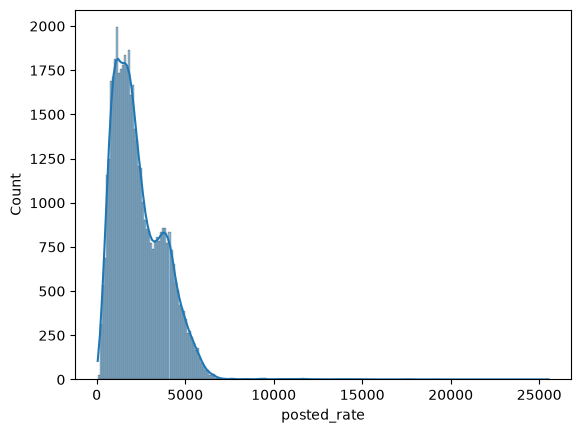

In [10]:
sns.histplot(df["posted_rate"], kde=True)
plt.show()

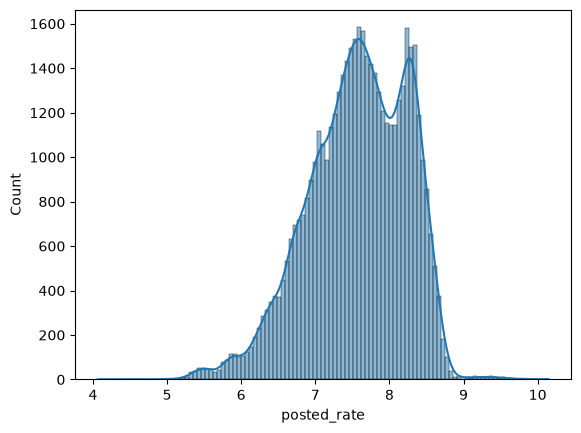

In [24]:
sns.histplot(np.log1p(df["posted_rate"]), kde=True)
plt.show()

## Numerical Feature Analysis
Study distributions and detect potential outliers.

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance',
       'weight', 'market_index', 'quote_signal', 'posted_rate'],
      dtype='str')

In [12]:
df[numerical_cols].describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


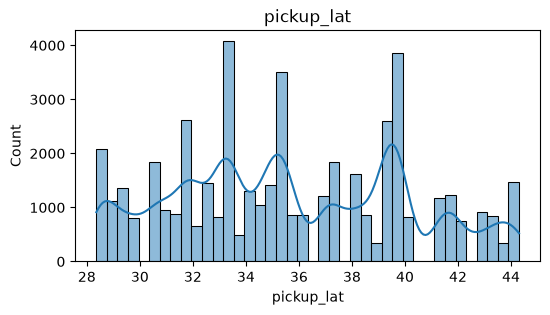

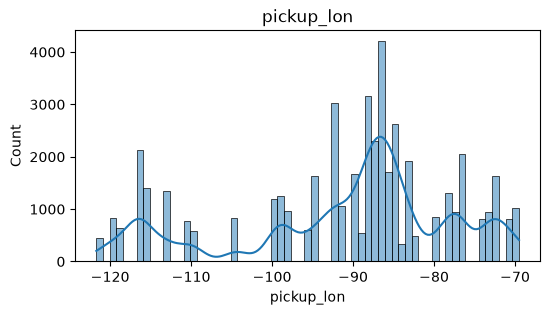

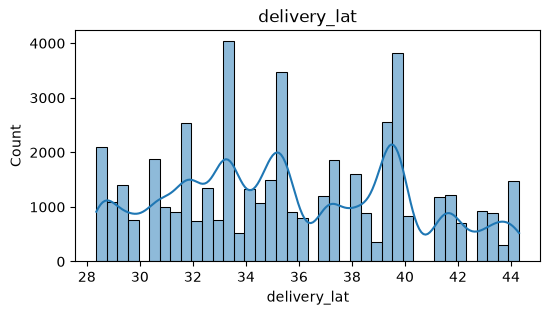

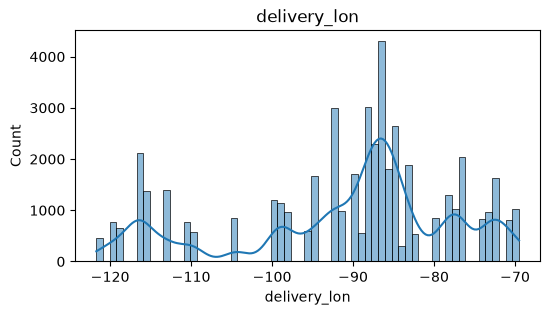

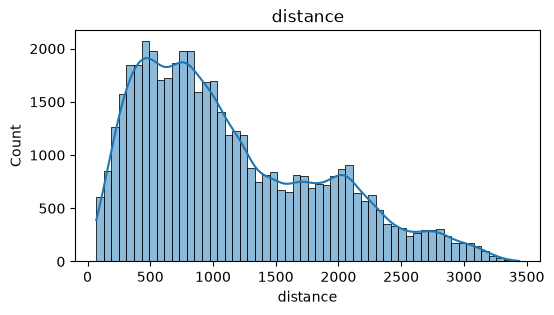

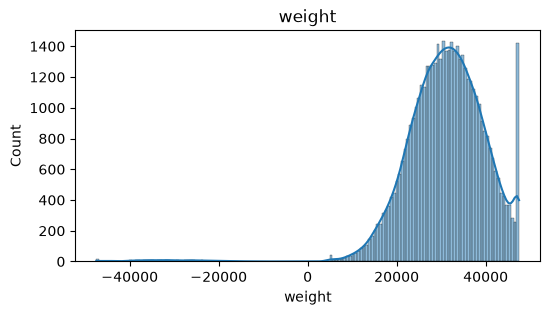

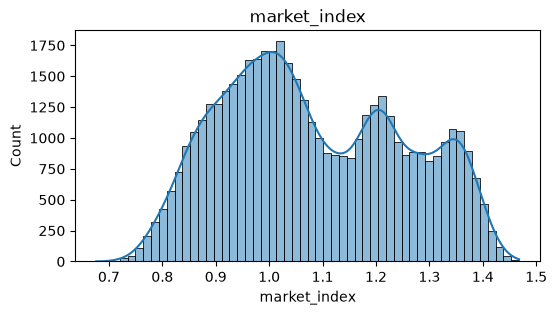

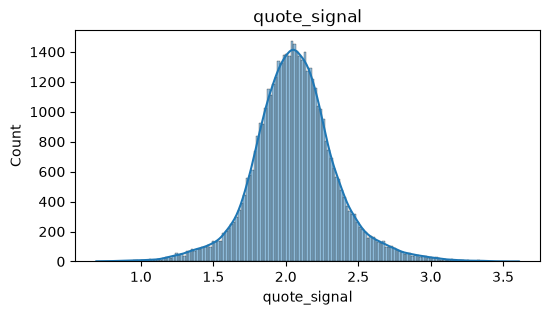

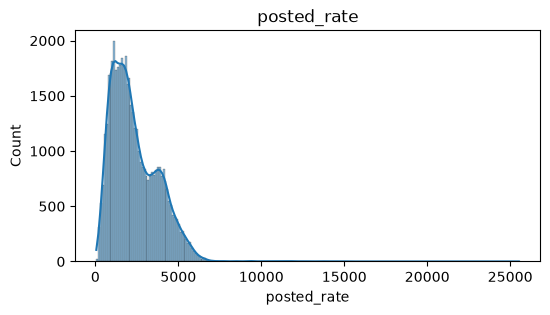

In [31]:

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

## Outlier Detection
Identify extreme values using boxplots.

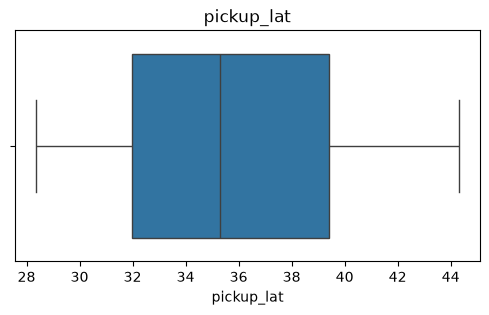

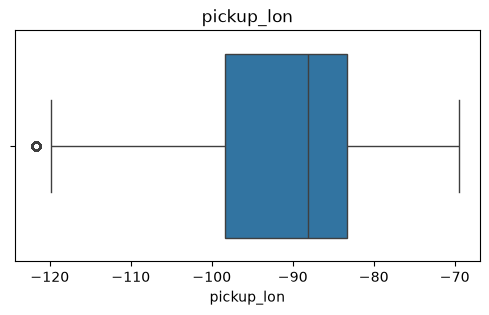

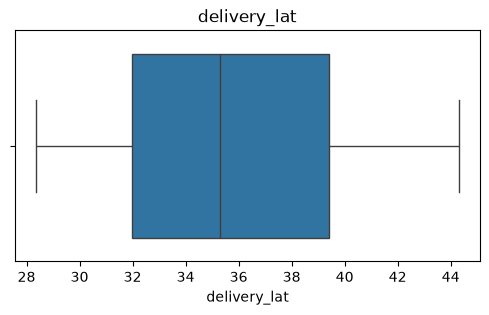

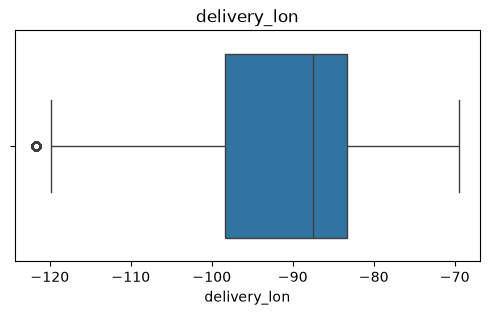

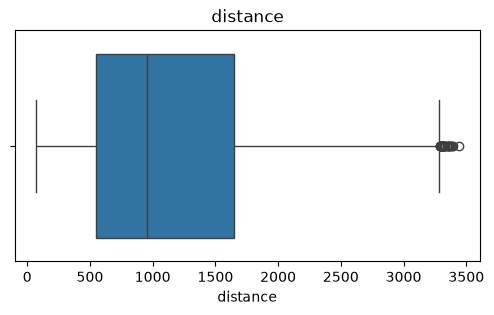

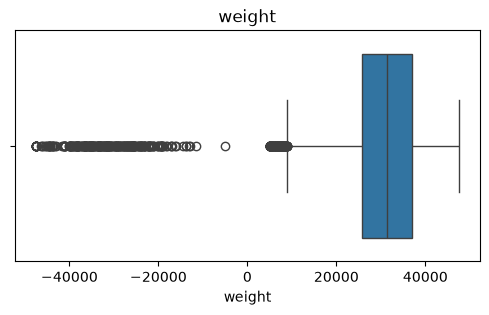

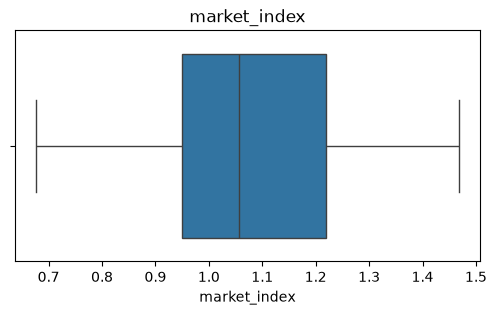

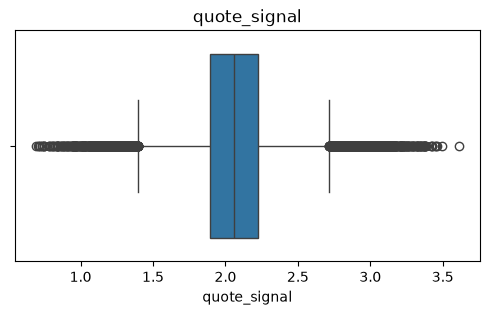

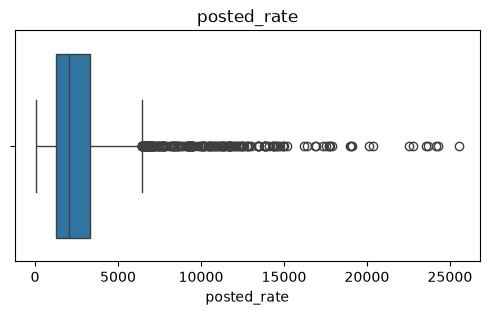

In [30]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Categorical Feature Analysis
Inspect category frequencies and identify rare categories.

In [15]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

/var/folders/4c/5h0nzz294t390b8nn0gqgtl80000gn/T/ipykernel_98509/2424776929.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['load_id', 'pickup', 'delivery', 'equipment', 'date'], dtype='str')

In [32]:
for col in categorical_cols:
    print(f'{col}:{df[col].nunique()}')

load_id:48000
pickup:64
delivery:64
equipment:3
date:304


In [17]:
df['equipment'].value_counts()

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

## Missing Value Analysis
Determine which columns contain missing values and how many.

In [18]:
missing = df.isnull().sum()

missing[missing > 0]

weight          300
market_index    374
dtype: int64

## Correlation Analysis
Measure relationships between target and other numerical features.


In [19]:
corr = df.corr(numeric_only=True)
corr['posted_rate']

pickup_lat     -0.090873
pickup_lon     -0.255058
delivery_lat   -0.091970
delivery_lon   -0.257086
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
posted_rate     1.000000
Name: posted_rate, dtype: float64

## negative value


In [20]:
df[df["weight"] < 0]

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,33.17137,-104.36789,39.87206,-85.62931,1334.2,Reefer,-36559.0,2025-01-01,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,33.07921,-119.79528,30.92733,-113.23037,496.2,Dry Van,-26670.0,2025-01-02,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,34.63570,-83.28506,35.37376,-77.47605,411.3,Reefer,-20003.0,2025-01-02,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,35.98195,-82.78379,29.87534,-99.85456,1317.4,Reefer,-23981.0,2025-01-02,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,41.70243,-89.85588,37.37287,-69.50000,1331.1,Dry Van,-41397.0,2025-01-03,0.94787,1.91867,2522.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47404,TR-047405,Baton Rouge,Memphis,30.50134,-92.65374,35.56802,-89.52871,468.7,Dry Van,-24142.0,2025-10-28,0.94219,1.83201,1077.64
47431,TR-047432,Phoenix,Chattanooga,28.75668,-115.87725,35.29792,-87.18651,1978.6,Flatbed,-35617.0,2025-10-28,0.92870,2.00708,4295.45
47735,TR-047736,Houston,Reno,30.71157,-94.76550,39.54838,-118.64843,1689.1,Reefer,-43951.0,2025-10-30,1.04615,1.85824,3933.12
47850,TR-047851,Shreveport,Cincinnati,32.54628,-92.31888,37.15706,-86.77499,538.3,Dry Van,-28144.0,2025-10-31,0.98093,1.86958,1191.61


# EDA Findings

### Missing Values
- weight: 300
- market_index: 374

### Outliers
- Weight contains extreme values.

### Invalid Data
- Negative weights detected.

### Categorical Features
- Pickup: 64 categories
- Delivery: 64 categories

### Correlation
- Distance positively correlates with target.

### Actions
- Handle missing values.
- Remove or correct negative weights.
- Encode categorical variables.
- Scale numerical features if required.